# IT Fusion — MARIA Training (Image + Text Cross-Modal Fusion)
Trains FusionClassifier using EfficientFormerV2 image features (288-d) and Bio_ClinicalBERT text features (768-d)
with MARIA-style cross-modal attention. Classes grouped to Top-50 + Other for learnability.

In [ ]:
from huggingface_hub import login

# Replace with your new token from https://huggingface.co/settings/tokens
HF_TOKEN = "****"

login(token=HF_TOKEN, add_to_git_credential=False)
print("✓ HuggingFace login successful")

✓ HuggingFace login successful


In [19]:
import os, sys, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, LambdaLR
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path

FUSION_DIR = Path('/home/vjti-comp/Desktop/Final Project Code/it_fusion_modular_project')
sys.path.insert(0, str(FUSION_DIR))

from maria_fusion import FusionClassifier

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

Device: cuda


## Config

In [20]:
DATASET_PATH = Path('/data/Stagewise Dataset/IT Fusion/prepared/it_fusion_maria_dataset.parquet')
CHECKPOINT_DIR = FUSION_DIR / 'checkpoints'
CHECKPOINT_DIR.mkdir(exist_ok=True)

# ── Class grouping ──
TOP_K_CLASSES = 50   # keep top-50 most frequent classes, rest → 'Other'

# ── Feature dimensions (from dataset) ──
IMAGE_DIM = 288   # EfficientFormerV2-S2
TEXT_DIM  = 768   # Bio_ClinicalBERT

# ── Training hyperparameters ──
BATCH_SIZE   = 64
EPOCHS       = 50     # increased from 30 — model was still improving
LR           = 3e-4
WEIGHT_DECAY = 1e-4
D_MODEL      = 256
N_HEADS      = 8
N_LAYERS     = 3
DROPOUT      = 0.2
LABEL_SMOOTH = 0.1
WARMUP_EPOCHS= 3
PATIENCE     = 10    # early stopping patience
TRAIN_SPLIT  = 0.70
VAL_SPLIT    = 0.15
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
print('Config set')

Config set


## Dataset (Image + Text Features with Class Grouping)

In [21]:
class ITFusionDataset(Dataset):
    """Reads pre-extracted image & text features with top-K class grouping."""

    def __init__(self, parquet_path, top_k=50):
        df = pd.read_parquet(parquet_path)
        df = df[df['target_class'] >= 0].reset_index(drop=True)
        print(f'Loaded {len(df)} labeled samples, {df["target_class"].nunique()} original classes')
        print(df['dataset'].value_counts().to_string())

        # ── Group to top-K classes ──
        vc = df['target_class'].value_counts()
        top_classes = set(vc.head(top_k).index.tolist())
        print(f'\nKeeping top-{top_k} classes ({sum(vc.head(top_k))} samples)')
        print(f'Remaining {len(vc) - top_k} classes → "Other"')

        # Build remapping: original_class → new_class (0..top_k)
        sorted_top = sorted(top_classes)
        self.class_remap = {orig: new_idx for new_idx, orig in enumerate(sorted_top)}
        self.other_idx = top_k  # last index = 'Other'

        df['grouped_class'] = df['target_class'].apply(
            lambda c: self.class_remap.get(c, self.other_idx)
        )

        # Build label names
        label2name = df.drop_duplicates('target_class').set_index('target_class')['disease_label'].to_dict()
        self.class_names = [label2name.get(c, str(c)) for c in sorted_top] + ['Other']
        self.n_classes = top_k + 1

        self.df = df
        print(f'Final class count: {self.n_classes}')
        print(f'\nGrouped class distribution (top 10):')
        gvc = df['grouped_class'].value_counts().head(10)
        for idx in gvc.index:
            print(f'  [{idx:2d}] {self.class_names[idx][:50]:50s} → {gvc[idx]:>6d}')

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_feat = torch.tensor(row['image_features'], dtype=torch.float32)
        txt_feat = torch.tensor(row['text_features'],  dtype=torch.float32)
        label    = torch.tensor(int(row['grouped_class']), dtype=torch.long)

        # Masks: 1.0 if features are non-zero (present), 0.0 if missing
        img_mask = torch.tensor(1.0 if img_feat.abs().sum() > 1e-6 else 0.0)
        txt_mask = torch.tensor(1.0 if txt_feat.abs().sum() > 1e-6 else 0.0)

        return img_feat, txt_feat, img_mask, txt_mask, label


from sklearn.model_selection import train_test_split as sk_split
from torch.utils.data import Subset

full_ds = ITFusionDataset(DATASET_PATH, top_k=TOP_K_CLASSES)
N = len(full_ds)
all_labels = full_ds.df['grouped_class'].values

# Stratified split — ensures every class appears in train/val/test
train_idx, temp_idx = sk_split(
    np.arange(N), test_size=(1 - TRAIN_SPLIT),
    random_state=SEED, stratify=all_labels
)
val_ratio_of_temp = VAL_SPLIT / (1 - TRAIN_SPLIT)
val_idx, test_idx = sk_split(
    temp_idx, test_size=(1 - val_ratio_of_temp),
    random_state=SEED, stratify=all_labels[temp_idx]
)

train_ds = Subset(full_ds, train_idx)
val_ds   = Subset(full_ds, val_idx)
test_ds  = Subset(full_ds, test_idx)
print(f'Stratified split — train={len(train_idx)}  val={len(val_idx)}  test={len(test_idx)}')


Loaded 415508 labeled samples, 22708 original classes
dataset
DERM1M         413210
PAD-UFES-20      2298

Keeping top-50 classes (280027 samples)
Remaining 22658 classes → "Other"
Final class count: 51

Grouped class distribution (top 10):
  [50] Other                                              → 135481
  [34] no definitive diagnosis                            → 102380
  [ 2] allergic contact dermatitis                        →  47510
  [22] irritated seborrheic keratosis (from "sk/isk")     →  15906
  [37] psoriasis                                          →  13794
  [33] nevus                                              →   8706
  [30] melanoma                                           →   8025
  [15] eczema                                             →   6808
  [24] keratosis                                          →   4688
  [ 6] basal cell carcinoma                               →   4683
Stratified split — train=290855  val=62326  test=62327


In [22]:
def collate_fn(batch):
    img_feats = torch.stack([b[0] for b in batch])
    txt_feats = torch.stack([b[1] for b in batch])
    img_masks = torch.stack([b[2] for b in batch])
    txt_masks = torch.stack([b[3] for b in batch])
    labels    = torch.stack([b[4] for b in batch])
    return img_feats, txt_feats, img_masks, txt_masks, labels

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, collate_fn=collate_fn, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, collate_fn=collate_fn, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, collate_fn=collate_fn, pin_memory=True)
print(f'Batches: train={len(train_loader)}  val={len(val_loader)}  test={len(test_loader)}')

Batches: train=4545  val=974  test=974


## Model + Optimizer

In [23]:
n_classes = full_ds.n_classes
print(f'Classes: {n_classes} (top-{TOP_K_CLASSES} + Other)')

model = FusionClassifier(
    image_dim=IMAGE_DIM, text_dim=TEXT_DIM,
    d_model=D_MODEL, n_classes=n_classes,
    n_heads=N_HEADS, n_layers=N_LAYERS,
    dropout=DROPOUT
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params: {n_params:,}')

# Class-weighted loss with label smoothing
label_counts = np.bincount(
    full_ds.df['grouped_class'].values.astype(int), minlength=n_classes
)  # guarantees all n_classes entries even if some have 0 samples
class_weights = torch.tensor(1.0 / np.sqrt(label_counts + 1), dtype=torch.float32).to(DEVICE)
class_weights = class_weights / class_weights.sum() * n_classes
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTH)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Cosine schedule with linear warmup
def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = LambdaLR(optimizer, lr_lambda)
print('Model, loss, optimizer ready')

Classes: 51 (top-50 + Other)
Trainable params: 2,558,261
Model, loss, optimizer ready


## Training Loop

In [24]:
def train_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for img_f, txt_f, img_m, txt_m, labels in loader:
        img_f  = img_f.to(DEVICE)
        txt_f  = txt_f.to(DEVICE)
        img_m  = img_m.to(DEVICE)
        txt_m  = txt_m.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        logits, _, _ = model(img_f, txt_f, img_m, txt_m)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += len(labels)
    return total_loss / len(loader), correct / total

@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_gates = [], [], []
    for img_f, txt_f, img_m, txt_m, labels in loader:
        img_f  = img_f.to(DEVICE)
        txt_f  = txt_f.to(DEVICE)
        img_m  = img_m.to(DEVICE)
        txt_m  = txt_m.to(DEVICE)
        labels = labels.to(DEVICE)

        logits, _, gate_w = model(img_f, txt_f, img_m, txt_m)
        loss = criterion(logits, labels)

        total_loss += loss.item()
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total   += len(labels)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_gates.extend(gate_w.cpu().numpy())
    return total_loss / len(loader), correct / total, all_preds, all_labels, all_gates

print('Training functions defined')

Training functions defined


In [25]:
history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
best_val_acc = 0.0
epochs_no_improve = 0
BEST_CKPT = str(CHECKPOINT_DIR / 'maria_fusion_best.pt')

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader)
    vl_loss, vl_acc, _, _, _ = eval_epoch(model, val_loader)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    lr_now = optimizer.param_groups[0]['lr']
    print(f'Ep {epoch:3d}/{EPOCHS}  '
          f'tr_loss={tr_loss:.4f} tr_acc={tr_acc:.3f}  '
          f'vl_loss={vl_loss:.4f} vl_acc={vl_acc:.3f}  '
          f'lr={lr_now:.2e}')

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_CKPT)
        print(f'  ✓ Saved best checkpoint (val_acc={vl_acc:.4f})')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f'  ⚠ Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)')
            break

print(f'\nBest Val Acc: {best_val_acc:.4f}')
print(f'Total epochs trained: {len(history["train_loss"])}')

Ep   1/50  tr_loss=3.2608 tr_acc=0.607  vl_loss=2.8202 vl_acc=0.648  lr=2.00e-04
  ✓ Saved best checkpoint (val_acc=0.6484)
Ep   2/50  tr_loss=2.9059 tr_acc=0.624  vl_loss=2.6943 vl_acc=0.662  lr=3.00e-04
  ✓ Saved best checkpoint (val_acc=0.6617)
Ep   3/50  tr_loss=2.8159 tr_acc=0.639  vl_loss=2.6855 vl_acc=0.658  lr=3.00e-04
Ep   4/50  tr_loss=2.7059 tr_acc=0.661  vl_loss=2.5823 vl_acc=0.687  lr=3.00e-04
  ✓ Saved best checkpoint (val_acc=0.6871)
Ep   5/50  tr_loss=2.6357 tr_acc=0.676  vl_loss=2.5626 vl_acc=0.702  lr=2.99e-04
  ✓ Saved best checkpoint (val_acc=0.7023)
Ep   6/50  tr_loss=2.5850 tr_acc=0.688  vl_loss=2.5474 vl_acc=0.671  lr=2.97e-04
Ep   7/50  tr_loss=2.5478 tr_acc=0.696  vl_loss=2.4982 vl_acc=0.705  lr=2.95e-04
  ✓ Saved best checkpoint (val_acc=0.7054)
Ep   8/50  tr_loss=2.5117 tr_acc=0.704  vl_loss=2.4724 vl_acc=0.711  lr=2.92e-04
  ✓ Saved best checkpoint (val_acc=0.7110)
Ep   9/50  tr_loss=2.4838 tr_acc=0.711  vl_loss=2.4635 vl_acc=0.711  lr=2.88e-04
  ✓ Saved bes

## Results & Evaluation

In [26]:
# Load best checkpoint and evaluate on test set
model.load_state_dict(torch.load(BEST_CKPT, map_location=DEVICE))
ts_loss, ts_acc, preds, labels, gates = eval_epoch(model, test_loader)
print(f'Test Loss: {ts_loss:.4f}  Test Acc: {ts_acc:.4f}')

# Build target_names only for classes that appear in test set
present_classes = sorted(set(labels) | set(preds))
present_names   = [full_ds.class_names[c] if c < len(full_ds.class_names) else str(c)
                   for c in present_classes]

print('\nClassification Report:')
print(classification_report(labels, preds, labels=present_classes,
                           target_names=present_names, zero_division=0))

Test Loss: 2.3051  Test Acc: 0.7992

Classification Report:
                                                                          precision    recall  f1-score   support

                                                                    acne       0.60      0.77      0.67       364
actinic solar damage(actinic keratosis), basal cell carcinoma, keratosis       1.00      1.00      1.00       215
                                             allergic contact dermatitis       0.99      0.98      0.98      7127
             allergic contact dermatitis, contact dermatitis, dermatitis       0.78      0.78      0.78       153
                                                                alopecia       0.57      0.83      0.68       185
                                           atopic dermatitis, dermatitis       0.60      0.77      0.67       305
                                                    basal cell carcinoma       0.86      0.92      0.89       703
                           

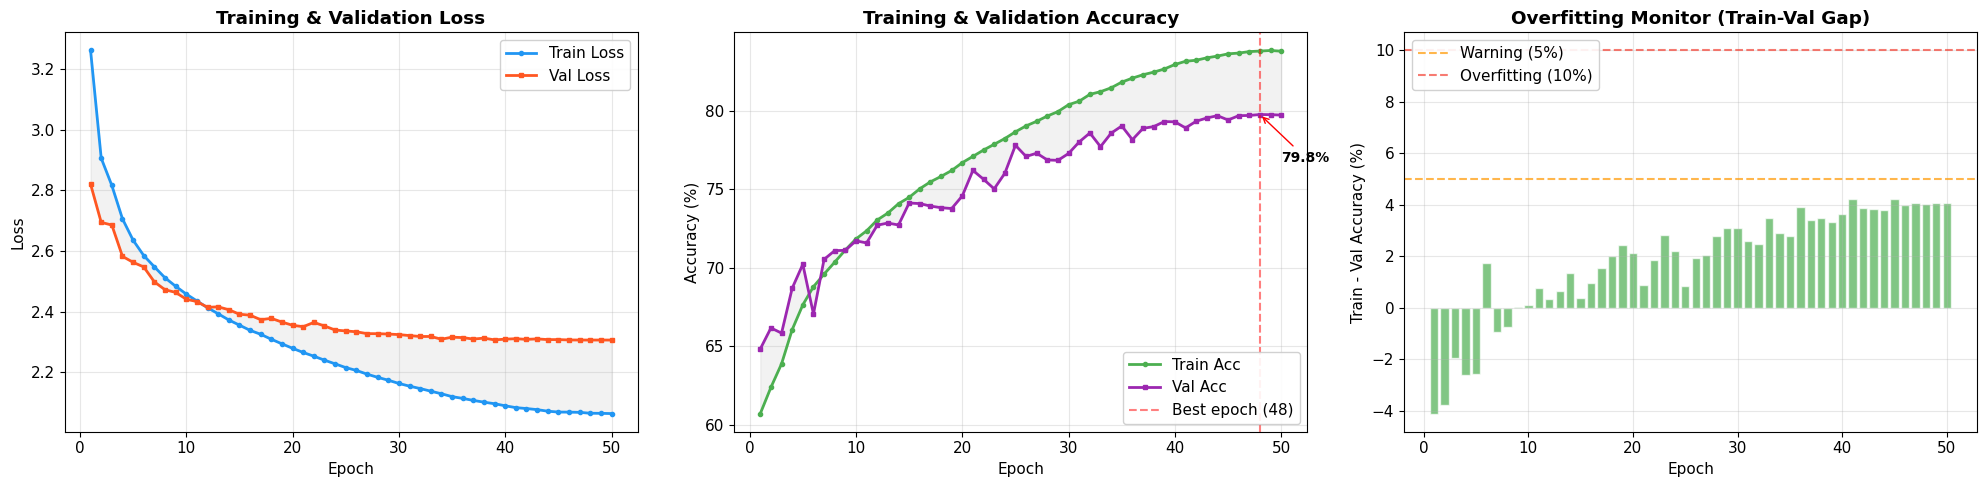

Training curves saved


In [27]:
# ═══════════════════════════════════════════════════════════════
# Professional Training Curves
# ═══════════════════════════════════════════════════════════════
import matplotlib
matplotlib.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.grid': True, 'grid.alpha': 0.3,
    'figure.facecolor': 'white'
})

epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ── Panel 1: Loss curves ──
ax = axes[0]
ax.plot(epochs_range, history['train_loss'], 'o-', ms=3, lw=2, label='Train Loss', color='#2196F3')
ax.plot(epochs_range, history['val_loss'],   's-', ms=3, lw=2, label='Val Loss',   color='#FF5722')
ax.fill_between(epochs_range, history['train_loss'], history['val_loss'], alpha=0.1, color='gray')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss', fontweight='bold')
ax.legend(loc='upper right', framealpha=0.9)

# ── Panel 2: Accuracy curves ──
ax = axes[1]
ax.plot(epochs_range, [a*100 for a in history['train_acc']], 'o-', ms=3, lw=2, label='Train Acc', color='#4CAF50')
ax.plot(epochs_range, [a*100 for a in history['val_acc']],   's-', ms=3, lw=2, label='Val Acc',   color='#9C27B0')
ax.fill_between(epochs_range,
                [a*100 for a in history['train_acc']],
                [a*100 for a in history['val_acc']], alpha=0.1, color='gray')
best_ep = np.argmax(history['val_acc']) + 1
best_va = max(history['val_acc']) * 100
ax.axvline(best_ep, ls='--', color='red', alpha=0.5, label=f'Best epoch ({best_ep})')
ax.annotate(f'{best_va:.1f}%', xy=(best_ep, best_va), fontsize=10, fontweight='bold',
            xytext=(best_ep+2, best_va-3), arrowprops=dict(arrowstyle='->', color='red'))
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.set_title('Training & Validation Accuracy', fontweight='bold')
ax.legend(loc='lower right', framealpha=0.9)

# ── Panel 3: Train-Val Gap (overfit monitor) ──
ax = axes[2]
gap = [((t - v) * 100) for t, v in zip(history['train_acc'], history['val_acc'])]
colors = ['#4CAF50' if g < 5 else '#FF9800' if g < 10 else '#F44336' for g in gap]
ax.bar(epochs_range, gap, color=colors, alpha=0.7, edgecolor='white')
ax.axhline(5, ls='--', color='#FF9800', alpha=0.7, label='Warning (5%)')
ax.axhline(10, ls='--', color='#F44336', alpha=0.7, label='Overfitting (10%)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Train - Val Accuracy (%)')
ax.set_title('Overfitting Monitor (Train-Val Gap)', fontweight='bold')
ax.legend(loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.savefig(str(CHECKPOINT_DIR / 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Training curves saved')

## Confusion Matrix (Top-15 Classes)

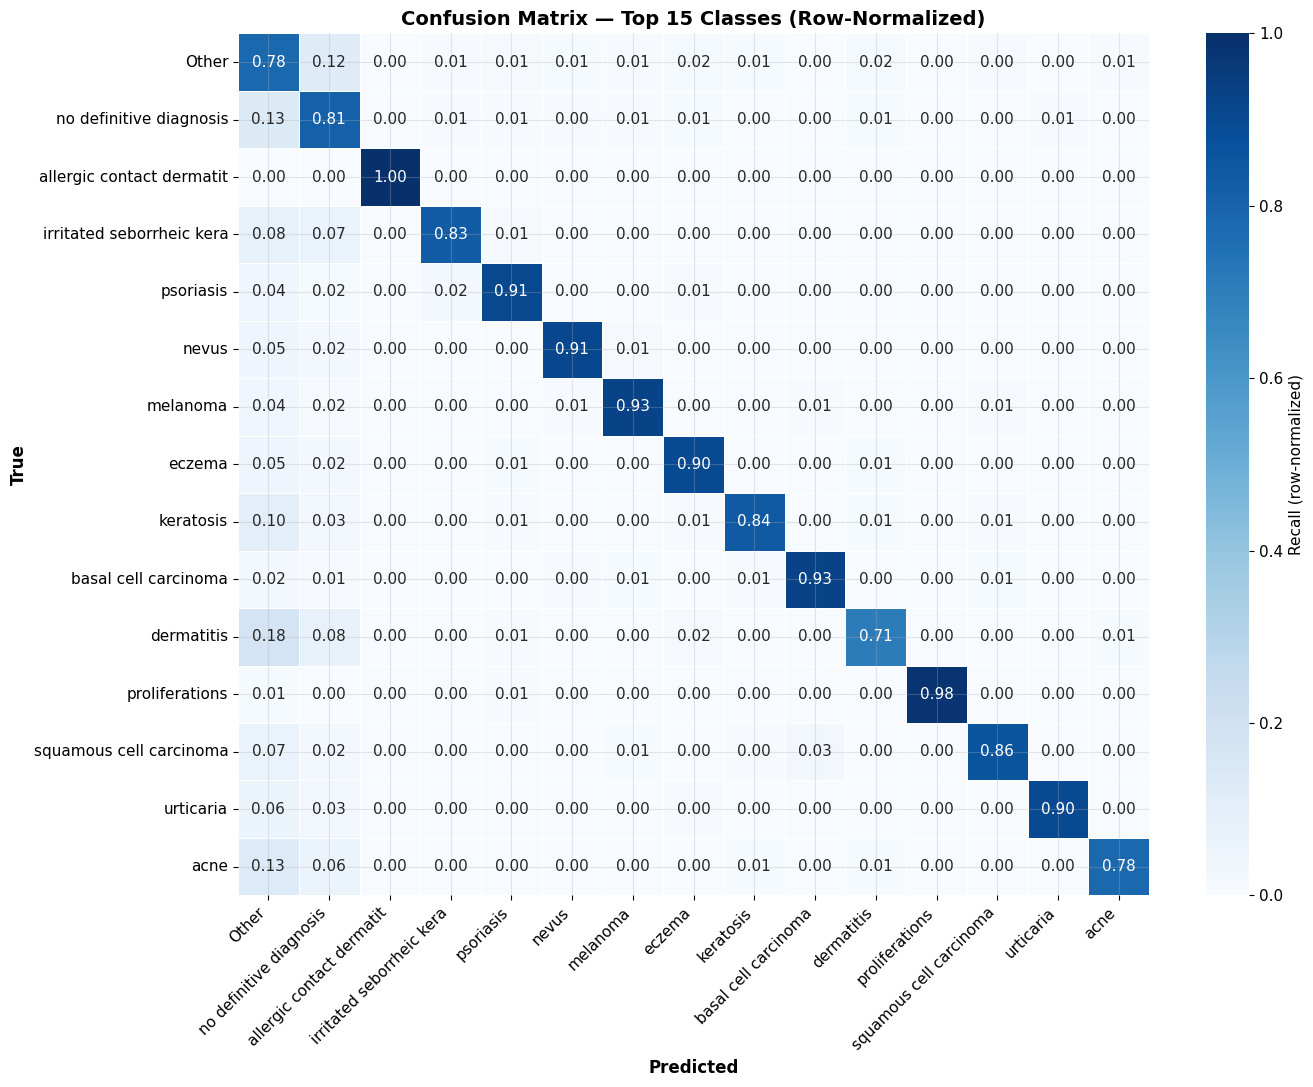

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get class counts for sorting
class_counts = full_ds.df['grouped_class'].value_counts().sort_values(ascending=False)
top15 = class_counts.head(15).index.tolist()

# Filter preds/labels to top-15
mask_top = [(l in top15 and p in top15) for l, p in zip(labels, preds)]
labels_t = [l for l, m in zip(labels, mask_top) if m]
preds_t  = [p for p, m in zip(preds,  mask_top) if m]

cm = confusion_matrix(labels_t, preds_t, labels=top15)
# Normalize by row (true class)
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-6)

top15_names = [full_ds.class_names[c][:25] for c in top15]

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=top15_names, yticklabels=top15_names,
            ax=ax, vmin=0, vmax=1, linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Recall (row-normalized)'})
ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax.set_ylabel('True', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix — Top 15 Classes (Row-Normalized)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(str(CHECKPOINT_DIR / 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

## Per-Class F1 Score

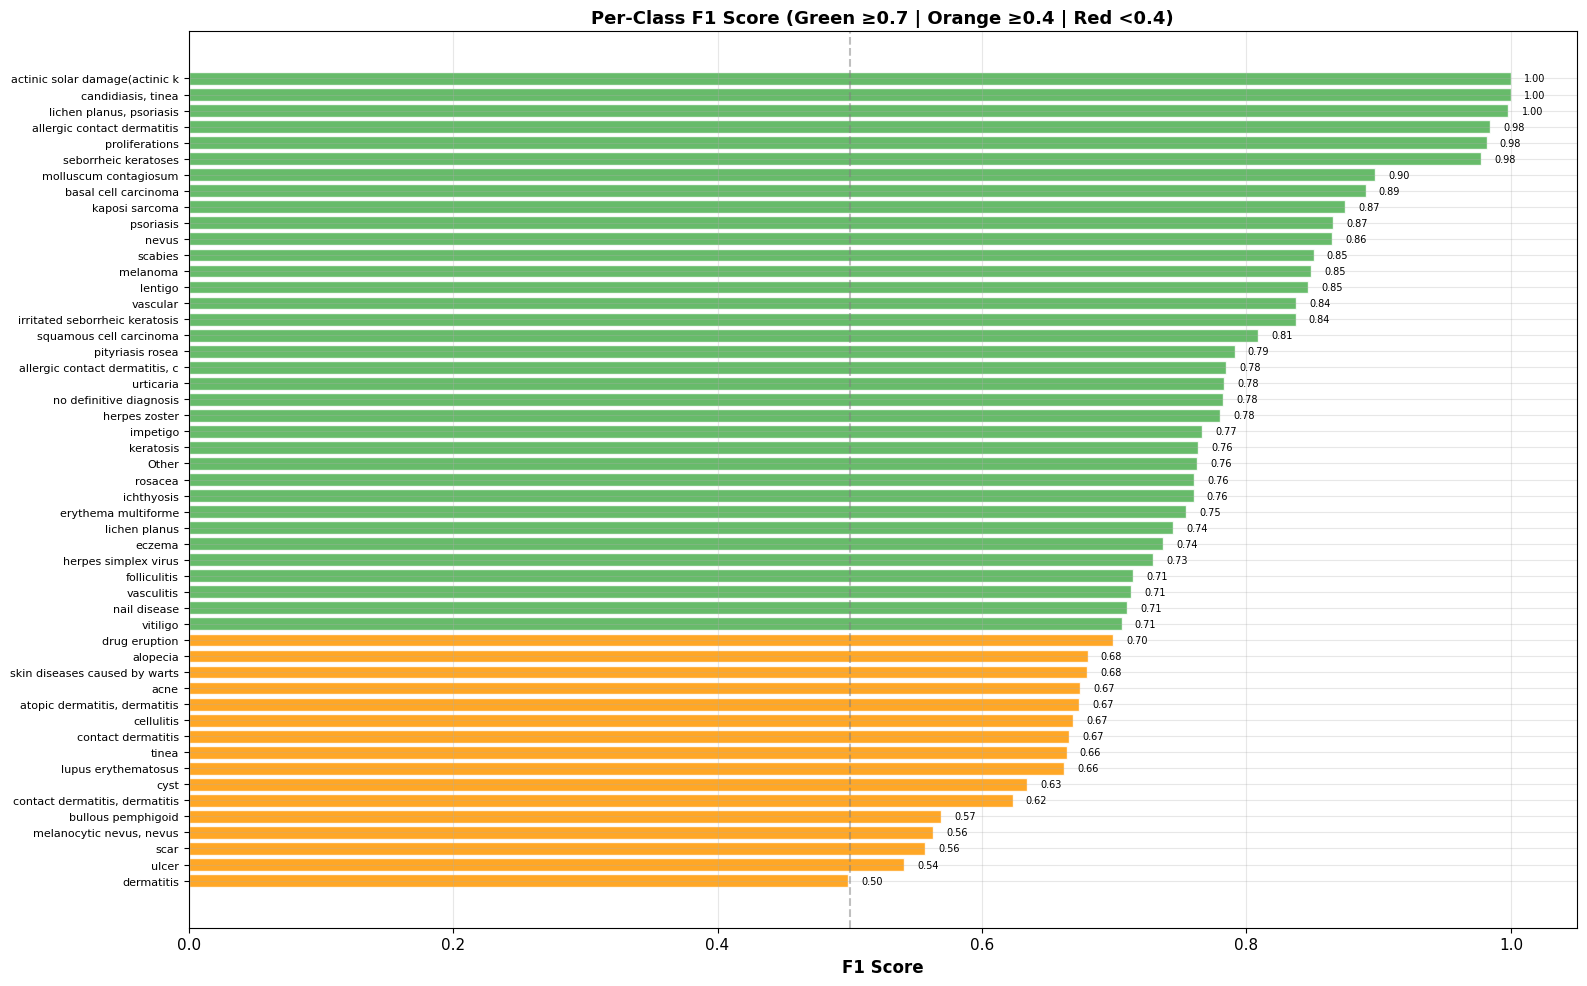

Macro F1:    0.7638
Weighted F1: 0.8016
Classes with F1 ≥ 0.7: 35/51
Classes with F1 < 0.3: 0/51


In [29]:
from sklearn.metrics import f1_score, precision_recall_fscore_support

present_classes = sorted(set(labels) | set(preds))
prec, rec, f1, sup = precision_recall_fscore_support(
    labels, preds, labels=present_classes, zero_division=0
)

# Sort by F1 descending
class_data = []
for i, c in enumerate(present_classes):
    name = full_ds.class_names[c] if c < len(full_ds.class_names) else str(c)
    class_data.append({'name': name[:30], 'f1': f1[i], 'prec': prec[i], 'rec': rec[i], 'support': sup[i]})

class_data.sort(key=lambda x: x['f1'], reverse=True)

fig, ax = plt.subplots(figsize=(16, 10))
names = [d['name'] for d in class_data]
f1s   = [d['f1'] for d in class_data]
colors = ['#4CAF50' if f >= 0.7 else '#FF9800' if f >= 0.4 else '#F44336' for f in f1s]

bars = ax.barh(range(len(names)), f1s, color=colors, edgecolor='white', alpha=0.85)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=8)
ax.set_xlabel('F1 Score', fontsize=12, fontweight='bold')
ax.set_title('Per-Class F1 Score (Green ≥0.7 | Orange ≥0.4 | Red <0.4)', fontsize=13, fontweight='bold')
ax.axvline(0.5, ls='--', color='gray', alpha=0.5)
ax.invert_yaxis()
ax.set_xlim(0, 1.05)

# Add value labels
for bar, f in zip(bars, f1s):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{f:.2f}', va='center', fontsize=7)

plt.tight_layout()
plt.savefig(str(CHECKPOINT_DIR / 'per_class_f1.png'), dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
macro_f1 = np.mean(f1s)
weighted_f1 = f1_score(labels, preds, labels=present_classes, average='weighted', zero_division=0)
print(f'Macro F1:    {macro_f1:.4f}')
print(f'Weighted F1: {weighted_f1:.4f}')
print(f'Classes with F1 ≥ 0.7: {sum(1 for f in f1s if f >= 0.7)}/{len(f1s)}')
print(f'Classes with F1 < 0.3: {sum(1 for f in f1s if f < 0.3)}/{len(f1s)}')

## Gate Weight Analysis (Image vs Text Reliance)

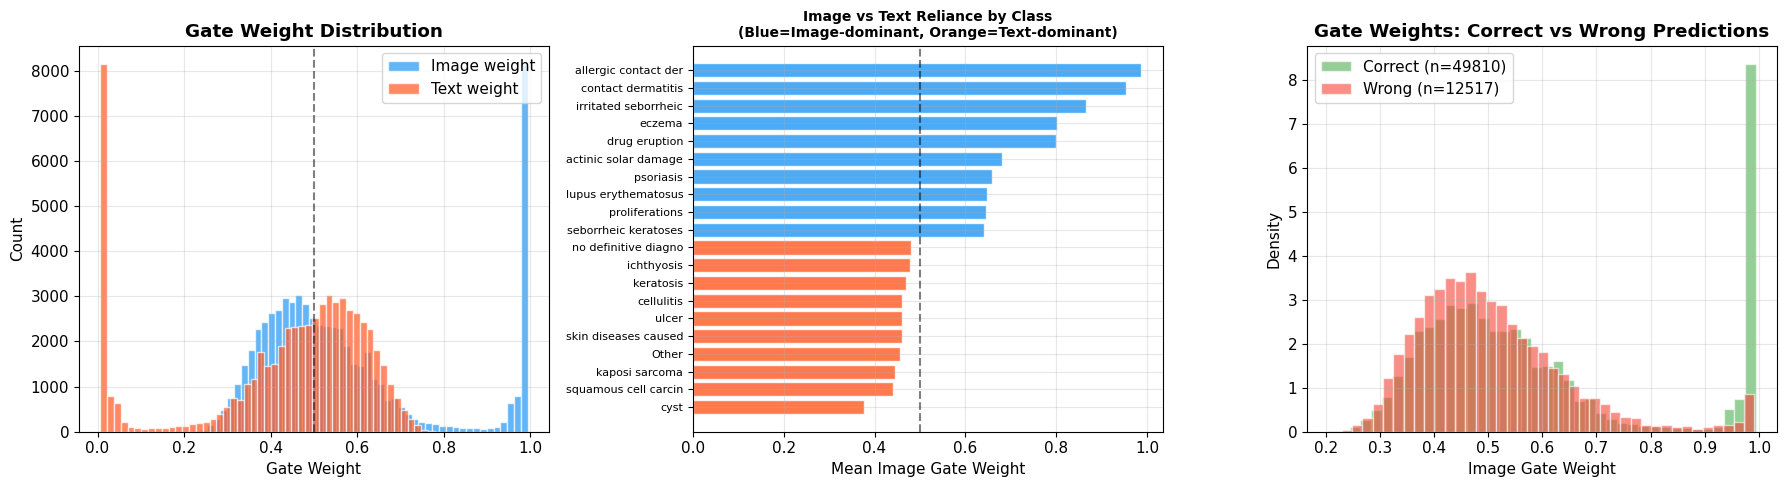

Mean image weight: 0.571 ± 0.207
Mean text weight:  0.429 ± 0.207


In [30]:
gates_arr = np.array(gates)  # (N, 2) — [image_weight, text_weight]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Panel 1: Overall distribution ──
ax = axes[0]
ax.hist(gates_arr[:, 0], bins=50, alpha=0.7, color='#2196F3', label='Image weight', edgecolor='white')
ax.hist(gates_arr[:, 1], bins=50, alpha=0.7, color='#FF5722', label='Text weight', edgecolor='white')
ax.axvline(0.5, ls='--', color='black', alpha=0.5)
ax.set_xlabel('Gate Weight'); ax.set_ylabel('Count')
ax.set_title('Gate Weight Distribution', fontweight='bold')
ax.legend()

# ── Panel 2: Per-class mean gate weight ──
ax = axes[1]
class_img_w = {}
for l, g in zip(labels, gates_arr):
    name = full_ds.class_names[l][:20] if l < len(full_ds.class_names) else str(l)
    if name not in class_img_w:
        class_img_w[name] = []
    class_img_w[name].append(g[0])

# Sort by mean image weight
sorted_classes = sorted(class_img_w.items(), key=lambda x: np.mean(x[1]), reverse=True)
top20 = sorted_classes[:10] + sorted_classes[-10:]
cnames = [c[0] for c in top20]
cmeans = [np.mean(c[1]) for c in top20]
colors2 = ['#2196F3' if m > 0.5 else '#FF5722' for m in cmeans]

ax.barh(range(len(cnames)), cmeans, color=colors2, edgecolor='white', alpha=0.8)
ax.set_yticks(range(len(cnames)))
ax.set_yticklabels(cnames, fontsize=8)
ax.axvline(0.5, ls='--', color='black', alpha=0.5)
ax.set_xlabel('Mean Image Gate Weight')
ax.set_title('Image vs Text Reliance by Class\n(Blue=Image-dominant, Orange=Text-dominant)', fontweight='bold', fontsize=10)
ax.invert_yaxis()

# ── Panel 3: Correct vs Incorrect gate weights ──
ax = axes[2]
correct_mask = [l == p for l, p in zip(labels, preds)]
correct_gates = gates_arr[correct_mask]
wrong_gates   = gates_arr[[not c for c in correct_mask]]

ax.hist(correct_gates[:, 0], bins=40, alpha=0.6, color='#4CAF50', label=f'Correct (n={len(correct_gates)})', density=True, edgecolor='white')
ax.hist(wrong_gates[:, 0],   bins=40, alpha=0.6, color='#F44336', label=f'Wrong (n={len(wrong_gates)})',     density=True, edgecolor='white')
ax.set_xlabel('Image Gate Weight'); ax.set_ylabel('Density')
ax.set_title('Gate Weights: Correct vs Wrong Predictions', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(str(CHECKPOINT_DIR / 'gate_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean image weight: {gates_arr[:, 0].mean():.3f} ± {gates_arr[:, 0].std():.3f}')
print(f'Mean text weight:  {gates_arr[:, 1].mean():.3f} ± {gates_arr[:, 1].std():.3f}')

## Summary

In [31]:
from sklearn.metrics import top_k_accuracy_score, f1_score

print('═' * 55)
print('          IT FUSION MODEL — FINAL METRICS')
print('═' * 55)
print(f'  Model:            FusionClassifier (MARIA cross-attn)')
print(f'  Parameters:       {n_params:,}')
print(f'  Classes:          {n_classes} (top-{TOP_K_CLASSES} + Other)')
print(f'  Epochs trained:   {len(history["train_loss"])}')
print(f'─' * 55)
print(f'  Best Val Acc:     {best_val_acc:.4f} ({best_val_acc*100:.1f}%)')
print(f'  Test Accuracy:    {ts_acc:.4f} ({ts_acc*100:.1f}%)')

present_classes_s = sorted(set(labels) | set(preds))
wf1 = f1_score(labels, preds, labels=present_classes_s, average='weighted', zero_division=0)
mf1 = f1_score(labels, preds, labels=present_classes_s, average='macro', zero_division=0)
print(f'  Weighted F1:      {wf1:.4f}')
print(f'  Macro F1:         {mf1:.4f}')
print(f'─' * 55)
print(f'  Train-Val Gap:    {(history["train_acc"][-1] - history["val_acc"][-1])*100:.1f}%')
print(f'  Overfit Status:   {"✅ No" if (history["train_acc"][-1] - history["val_acc"][-1]) < 0.05 else "⚠️ Mild" if (history["train_acc"][-1] - history["val_acc"][-1]) < 0.10 else "❌ Yes"}')
print(f'  Mean Gate (Img):  {gates_arr[:, 0].mean():.3f}')
print(f'  Mean Gate (Txt):  {gates_arr[:, 1].mean():.3f}')
print('═' * 55)

═══════════════════════════════════════════════════════
          IT FUSION MODEL — FINAL METRICS
═══════════════════════════════════════════════════════
  Model:            FusionClassifier (MARIA cross-attn)
  Parameters:       2,558,261
  Classes:          51 (top-50 + Other)
  Epochs trained:   50
───────────────────────────────────────────────────────
  Best Val Acc:     0.7976 (79.8%)
  Test Accuracy:    0.7992 (79.9%)
  Weighted F1:      0.8016
  Macro F1:         0.7638
───────────────────────────────────────────────────────
  Train-Val Gap:    4.1%
  Overfit Status:   ✅ No
  Mean Gate (Img):  0.571
  Mean Gate (Txt):  0.429
═══════════════════════════════════════════════════════


In [32]:
# Save full checkpoint with metadata
label2name = {i: name for i, name in enumerate(full_ds.class_names)}
full_ckpt = {
    'model_state': model.state_dict(),
    'n_classes': n_classes,
    'label2name': label2name,
    'class_names': full_ds.class_names,
    'class_remap': full_ds.class_remap,
    'best_val_acc': best_val_acc,
    'test_acc': ts_acc,
    'config': {
        'IMAGE_DIM': IMAGE_DIM, 'TEXT_DIM': TEXT_DIM,
        'D_MODEL': D_MODEL, 'N_HEADS': N_HEADS,
        'N_LAYERS': N_LAYERS, 'EPOCHS': EPOCHS,
        'BATCH_SIZE': BATCH_SIZE, 'LR': LR,
        'DROPOUT': DROPOUT, 'TOP_K_CLASSES': TOP_K_CLASSES,
    }
}
torch.save(full_ckpt, str(CHECKPOINT_DIR / 'maria_fusion_full_checkpoint.pt'))
print('Full checkpoint saved.')
print(f'Final Test Accuracy: {ts_acc:.4f}')

Full checkpoint saved.
Final Test Accuracy: 0.7992


## Demo: Sample Predictions
Shows 10 random test samples with model predictions, confidence, and image/text gate weights.

In [33]:
# ── Pick 10 random test samples and show predictions ──
model.eval()
demo_indices = np.random.choice(len(test_ds), size=10, replace=False)

print(f'{"#":>3} {"True Label":40s} {"Predicted":40s} {"Conf":>6s} {"Img_W":>6s} {"Txt_W":>6s} {"✓/✗":>4s}')
print('─' * 145)

n_correct = 0
for i, didx in enumerate(demo_indices):
    img_f, txt_f, img_m, txt_m, label = test_ds[didx]
    img_f = img_f.unsqueeze(0).to(DEVICE)
    txt_f = txt_f.unsqueeze(0).to(DEVICE)
    img_m = img_m.view(1).to(DEVICE)  # scalar → [1] for B=1
    txt_m = txt_m.view(1).to(DEVICE)  # scalar → [1] for B=1

    with torch.no_grad():
        logits, _, gate_w = model(img_f, txt_f, img_m, txt_m)
        probs = F.softmax(logits, dim=-1)
        pred_idx = probs.argmax(1).item()
        confidence = probs[0, pred_idx].item()
        img_w = gate_w[0, 0].item()
        txt_w = gate_w[0, 1].item()

    true_name = full_ds.class_names[label.item()][:40]
    pred_name = full_ds.class_names[pred_idx][:40]
    match = '✓' if label.item() == pred_idx else '✗'
    if label.item() == pred_idx:
        n_correct += 1

    print(f'{i+1:3d} {true_name:40s} {pred_name:40s} {confidence:6.3f} {img_w:6.3f} {txt_w:6.3f} {match:>4s}')

print('─' * 145)
print(f'Demo accuracy: {n_correct}/10 ({n_correct*10}%)')
print(f'\nGate weights show how much the model relies on Image vs Text for each sample.')

  # True Label                               Predicted                                  Conf  Img_W  Txt_W  ✓/✗
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  1 Other                                    Other                                     0.411  0.382  0.618    ✓
  2 no definitive diagnosis                  no definitive diagnosis                   0.525  0.522  0.478    ✓
  3 allergic contact dermatitis              allergic contact dermatitis               0.705  0.990  0.010    ✓
  4 Other                                    Other                                     0.400  0.321  0.679    ✓
  5 no definitive diagnosis                  no definitive diagnosis                   0.549  0.428  0.572    ✓
  6 no definitive diagnosis                  no definitive diagnosis                   0.568  0.449  0.551    ✓
  7 scar                                     scar                     

In [42]:
import inspect, os

# Get exact path of the file Python is actually importing
file_path = inspect.getfile(text_enc.__class__)
print(f'Actual file on disk: {file_path}')

new_content = r"""
import torch
import torch.nn as nn
from pathlib import Path
import sys

MEDPROC_DIR = Path('/home/vjti-comp/Desktop/Final Project Code/MedProc')
sys.path.insert(0, str(MEDPROC_DIR))

class TextEncoder(nn.Module):
    def __init__(self, checkpoint_path=None, device='cuda' if torch.cuda.is_available() else 'cpu'):
        super().__init__()
        self.device = device
        if checkpoint_path is None:
            checkpoint_path = MEDPROC_DIR / 'checkpoints' / 'medproc_checkpoint.pt'
        checkpoint_path = Path(checkpoint_path)
        if checkpoint_path.exists():
            print(f"Loading MedProc checkpoint from {checkpoint_path}...")
            ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
            self.label_map        = ckpt.get('label_map', {})
            self.symptom_keywords = ckpt.get('symptom_keywords', [])
            self.icd_threshold    = ckpt.get('icd_threshold', 0.35)
            self.sym_threshold    = ckpt.get('sym_threshold', 0.30)
            self._init_medproc_model(ckpt)
            self.medproc_model.eval()
            print(f"✓ MedProc model loaded successfully")
            print(f"  - ICD classes: {len(self.label_map)}")
        else:
            print(f"⚠ MedProc checkpoint not found at {checkpoint_path}")
            self.medproc_model    = None
            self.tokenizer        = None
            self.label_map        = {}
            self.symptom_keywords = []
            self.icd_threshold    = 0.35
            self.sym_threshold    = 0.30
        self.feature_dim = 768

    def _init_medproc_model(self, ckpt):
        try:
            from medproc_model import MedProcMultiTaskModel, MODEL_NAME
            from transformers import AutoTokenizer
            self.tokenizer = ckpt.get('tokenizer')
            if self.tokenizer is None:
                self.tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
            num_icd_labels = len(ckpt.get('label_map', {}))
            self.medproc_model = MedProcMultiTaskModel(
                model_name=MODEL_NAME, num_icd_labels=num_icd_labels
            ).to(self.device)
            if 'model_state' in ckpt:
                self.medproc_model.load_state_dict(ckpt['model_state'])
            elif 'state_dict' in ckpt:
                self.medproc_model.load_state_dict(ckpt['state_dict'])
        except Exception as e:
            print(f"⚠ Could not initialize MedProc model: {e}")
            self.medproc_model = None
            self.tokenizer     = None

    def forward(self, text):
        if self.medproc_model is None or self.tokenizer is None:
            batch_size = 1 if isinstance(text, str) else len(text)
            return torch.zeros(batch_size, 768, device=self.device), {
                'evolution_score': 0.0, 'symptom_keywords': [],
                'symptom_detected': False, 'top_icd_prefix': 'unknown'
            }
        if isinstance(text, str):
            text = [text]
        encoded = self.tokenizer(
            text, max_length=512, truncation=True,
            padding='max_length', return_tensors='pt'
        ).to(self.device)
        with torch.no_grad():
            input_ids      = encoded['input_ids']
            attention_mask = encoded['attention_mask']
            icd_logits, symptom_logits = self.medproc_model(input_ids, attention_mask)
            bert_out        = self.medproc_model.bert(
                input_ids=input_ids, attention_mask=attention_mask)
            pooled_features = bert_out.pooler_output
            icd_probs       = torch.sigmoid(icd_logits)
            symptom_score   = torch.sigmoid(symptom_logits).squeeze().item()
            top_idx         = int(icd_probs.argmax(dim=-1).item())
            top_icd         = self.label_map.get(str(top_idx),
                              self.label_map.get(top_idx, 'unknown'))
            predictions = {
                'icd_logits':       icd_logits.cpu().numpy(),
                'icd_preds':        (icd_probs > self.icd_threshold).cpu().numpy(),
                'symptom_logits':   symptom_logits.cpu().numpy(),
                'symptom_detected': symptom_score >= self.sym_threshold,
                'evolution_score':  round(symptom_score, 4),
                'symptom_keywords': self.symptom_keywords,
                'top_icd_prefix':   top_icd,
                'icd_classes':      self.label_map,
            }
        return pooled_features, predictions
"""

with open(file_path, 'w') as f:
    f.write(new_content)

# Verify
with open(file_path) as f:
    written = f.read()
assert 'self.projection' not in written, "FAILED"
assert 'weights_only=False' in written,  "FAILED"
print('✓ File rewritten')
print(f'  Size: {len(written)} chars')

# Now patch live object too so current session works without restart
import types, torch

def _fwd(self, text):
    if self.medproc_model is None or self.tokenizer is None:
        bs = 1 if isinstance(text, str) else len(text)
        return torch.zeros(bs, 768, device=self.device), {
            'evolution_score': 0.0, 'symptom_keywords': [],
            'symptom_detected': False, 'top_icd_prefix': 'unknown'}
    if isinstance(text, str): text = [text]
    enc = self.tokenizer(text, max_length=512, truncation=True,
                         padding='max_length', return_tensors='pt').to(self.device)
    with torch.no_grad():
        ids, msk = enc['input_ids'], enc['attention_mask']
        icd_l, sym_l = self.medproc_model(ids, msk)
        pool = self.medproc_model.bert(input_ids=ids, attention_mask=msk).pooler_output
        icd_p = torch.sigmoid(icd_l)
        sym_s = torch.sigmoid(sym_l).squeeze().item()
        ti    = int(icd_p.argmax(dim=-1).item())
        ticd  = self.label_map.get(str(ti), self.label_map.get(ti, 'unknown'))
        preds = {
            'icd_logits': icd_l.cpu().numpy(), 'icd_preds': (icd_p > self.icd_threshold).cpu().numpy(),
            'symptom_logits': sym_l.cpu().numpy(), 'symptom_detected': sym_s >= self.sym_threshold,
            'evolution_score': round(sym_s, 4), 'symptom_keywords': self.symptom_keywords,
            'top_icd_prefix': ticd, 'icd_classes': self.label_map}
    return pool, preds

text_enc.forward = types.MethodType(_fwd, text_enc)
if hasattr(text_enc, 'projection'): del text_enc.projection
print('✓ Live object patched')
print('→ Run inference cell now')

Actual file on disk: /home/vjti-comp/Desktop/Final Project Code/it_fusion_modular_project/text_encoder.py
✓ File rewritten
  Size: 4442 chars
✓ Live object patched
→ Run inference cell now


In [43]:
# ═══════════════════════════════════════════════════════════════════════════
# FULL JSON OUTPUT — End-to-end inference for any input image + disease text
# Runs: HC backbone → Text encoder → FusionClassifier → ABCDE → Drug rules
#       → Uncertainty detector → Clinical JSON
#
# INPUTS (edit these):
#   IMAGE_INPUT  : path to a skin lesion image file
#   CLINICAL_TEXT: clinical note / caption describing the lesion
#   PATIENT_INFO : age, gender, and any relevant history flags
# ═══════════════════════════════════════════════════════════════════════════

import sys, json, cv2
import numpy as np
import torch
import torch.nn.functional as F
from pathlib import Path
from PIL import Image
from torchvision import transforms

sys.path.insert(0, str(FUSION_DIR))
from maria_fusion      import FusionClassifier
from abcde_computation import compute_abcde
from abcde_inference   import interpret_abcde, abcde_to_feature_vector
from drug_rules        import recommend_treatment
from uncertainty_detector import detect_uncertainty
from json_builder      import build_json_from_modules, to_json_string
from hc_model          import load_hc_backbone
from text_encoder      import TextEncoder

# ─────────────────────────────────────────────────────────────────────────────
# ▼ EDIT THESE ▼
# ─────────────────────────────────────────────────────────────────────────────
IMAGE_INPUT   = '/data/Stagewise Dataset/IT Fusion/Derm1M/validation_data/y9OzN3-OlSU_frame_54698_0.jpg'   # any skin lesion image
CLINICAL_TEXT = (
    "58-year-old male with a growing pigmented lesion on the left forearm. "
    "Enlarging over 3 months with colour change from brown to black. "
    "Itching and occasional bleeding noted. Asymmetric border on dermoscopy."
)
PATIENT_INFO  = {
    'age':    58,
    'gender': 'M',
    # history flags used by drug contraindication checker:
    'autoimmune':        False,
    'immunosuppressed':  False,
    'pregnant':          False,
    'transplant':        False,
    'heart_failure':     False,
    'renal_impairment':  False,
    'hepatic_impairment':False,
    'braf_wildtype':     False,   # set True if BRAF wild-type confirmed
}
PIXEL_SPACING_MM = 0.1   # set from dermoscope calibration if known
# ─────────────────────────────────────────────────────────────────────────────
# ▲ EDIT THESE ▲
# ─────────────────────────────────────────────────────────────────────────────

DIVIDER = '─' * 65

# ── Load FusionClassifier from checkpoint ─────────────────────────────────────
print(DIVIDER)
print('Loading IT Fusion checkpoint...')
FULL_CKPT_PATH = str(CHECKPOINT_DIR / 'maria_fusion_full_checkpoint.pt')
ckpt = torch.load(FULL_CKPT_PATH, map_location=DEVICE, weights_only=False)

cfg = ckpt['config']
fusion_model = FusionClassifier(
    image_dim = cfg['IMAGE_DIM'],
    text_dim  = cfg['TEXT_DIM'],
    d_model   = cfg['D_MODEL'],
    n_classes = ckpt['n_classes'],
    n_heads   = cfg['N_HEADS'],
    n_layers  = cfg['N_LAYERS'],
    dropout   = cfg['DROPOUT'],
).to(DEVICE)
fusion_model.load_state_dict(ckpt['model_state'])
fusion_model.eval()

label2name  = ckpt['label2name']       # {int_idx -> disease_name}
class_names = ckpt['class_names']      # list[str]
print(f'✓ FusionClassifier loaded — {ckpt["n_classes"]} classes')
print(f'  Best val acc : {ckpt["best_val_acc"]*100:.1f}%')
print(f'  Test acc     : {ckpt["test_acc"]*100:.1f}%')

# ── Load HC backbone (EfficientFormerV2-S2 → 288-dim image features) ──────────
print(DIVIDER)
print('Loading HC backbone...')
hc_backbone = load_hc_backbone(device=DEVICE)

# ── Load Text encoder (Bio_ClinicalBERT → 768-dim text features) ─────────────
print('Loading Text encoder...')
HC_MEDPROC_CKPT = str('/data/Stagewise Dataset/MedProc/checkpoints/medproc_checkpoint.pt')
text_enc = TextEncoder(checkpoint_path=HC_MEDPROC_CKPT, device=DEVICE)
print('✓ Encoders ready')

# ── Step 1: Load and preprocess image ─────────────────────────────────────────
print(DIVIDER)
print(f'Processing image: {Path(IMAGE_INPUT).name}')

img_pil = Image.open(IMAGE_INPUT).convert('RGB')

# HC transform: 224×224 for EfficientFormerV2
hc_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
img_tensor = hc_transform(img_pil).unsqueeze(0).to(DEVICE)   # [1, 3, 224, 224]

# ABCDE mask: full-image fallback (replace with real ARCUNet mask if available)
img_np    = np.array(img_pil)                                  # H×W×3 RGB
mask_full = np.ones(img_np.shape[:2], dtype=np.uint8) * 255   # full-image mask
roi_rgb   = cv2.resize(img_np, (224, 224))                     # 224×224 RGB ROI
mask_224  = cv2.resize(mask_full, (224, 224), interpolation=cv2.INTER_NEAREST)

print(f'  Image size   : {img_pil.size}')
print(f'  Tensor shape : {tuple(img_tensor.shape)}')

# ── Step 2: Extract image features (288-dim) ──────────────────────────────────
with torch.no_grad():
    img_features = hc_backbone(img_tensor)                     # [1, 288]
    if img_features.dim() > 2:
        img_features = img_features.flatten(1)                 # flatten spatial dims
img_feat_np = img_features.squeeze(0).cpu().numpy()           # (288,)
print(f'  Image features shape: {img_feat_np.shape}')

# ── Step 3: Extract text features (768-dim) ───────────────────────────────────
txt_features, medproc_predictions = text_enc.forward(CLINICAL_TEXT)  # [1, 768]
txt_feat_np = txt_features.squeeze(0).cpu().detach().numpy()          # (768,)
print(f'  Text features shape : {txt_feat_np.shape}')

# Extract MedProc outputs for ABCDE and JSON
evolution_score   = float(medproc_predictions.get('evolution_score', 0.0))
symptom_keywords  = medproc_predictions.get('symptom_keywords', [])
top_icd_prefix    = medproc_predictions.get('top_icd_prefix', 'unknown')
print(f'  Evolution score     : {evolution_score:.3f}')
print(f'  Symptom keywords    : {symptom_keywords}')

# ── Step 4: FusionClassifier forward pass ─────────────────────────────────────
img_f = torch.tensor(img_feat_np, dtype=torch.float32).unsqueeze(0).to(DEVICE)
txt_f = torch.tensor(txt_feat_np, dtype=torch.float32).unsqueeze(0).to(DEVICE)
img_m = torch.tensor(1.0 if img_f.abs().sum() > 1e-6 else 0.0).view(1).to(DEVICE)
txt_m = torch.tensor(1.0 if txt_f.abs().sum() > 1e-6 else 0.0).view(1).to(DEVICE)

with torch.no_grad():
    logits, fused, gate_w = fusion_model(img_f, txt_f, img_m, txt_m)
    probs     = F.softmax(logits, dim=-1).squeeze(0)           # (n_classes,)
    pred_idx  = probs.argmax().item()
    maria_conf = probs[pred_idx].item()
    img_gate  = gate_w[0, 0].item()
    txt_gate  = gate_w[0, 1].item()

maria_class = label2name.get(str(pred_idx), label2name.get(pred_idx, 'Unknown'))

# Top-5 class probabilities
top5_idx   = probs.topk(5).indices.tolist()
top5_probs = probs.topk(5).values.tolist()
class_probs_dict = {
    label2name.get(str(i), label2name.get(i, str(i))): round(float(p), 4)
    for i, p in zip(top5_idx, top5_probs)
}

print(DIVIDER)
print(f'FusionClassifier result:')
print(f'  Predicted class : {maria_class}')
print(f'  Confidence      : {maria_conf:.4f}')
print(f'  Image gate      : {img_gate:.3f}  |  Text gate: {txt_gate:.3f}')
print(f'  Top-5 classes   :')
for cls_name, prob in class_probs_dict.items():
    bar = '█' * int(prob * 30)
    print(f'    {cls_name[:35]:<35} {bar:<30} {prob:.4f}')

# ── Step 5: ABCDE computation ─────────────────────────────────────────────────
print(DIVIDER)
print('Computing ABCDE scores...')
abcde_result = compute_abcde(
    mask             = mask_224,
    roi_img          = roi_rgb,           # RGB (abcde_computation handles conversion)
    evolution_score  = evolution_score,
    symptom_keywords = symptom_keywords,
    pixel_spacing_mm = PIXEL_SPACING_MM,
)
clinical_report = interpret_abcde(abcde_result, predicted_class=maria_class)

print(f'  A (Asymmetry)   : {abcde_result.A:.4f}  [{clinical_report.flags.A_grade}]')
print(f'  B (Border)      : {abcde_result.B:.4f}  [{clinical_report.flags.B_grade}]')
print(f'  C (Colour)      : {abcde_result.C:.4f}  [{clinical_report.flags.C_grade}]')
print(f'  D (Diameter)    : {abcde_result.D:.4f}  [{clinical_report.flags.D_grade}]')
print(f'  E (Evolution)   : {abcde_result.E:.4f}  [{clinical_report.flags.E_grade}]')
print(f'  Risk score      : {abcde_result.risk_score:.4f}')
print(f'  Risk level      : {abcde_result.risk_level}')
print(f'  Urgency         : {clinical_report.urgency}')

# ── Step 6: Drug recommendation ───────────────────────────────────────────────
print(DIVIDER)
print('Generating drug recommendation...')
drug_rec = recommend_treatment(
    predicted_class = maria_class,
    risk_level      = abcde_result.risk_level,
    patient_history = PATIENT_INFO,
)
print(f'  Condition       : {drug_rec.condition}')
print(f'  Surgical ref    : {drug_rec.surgical_referral}')
print(f'  Oncology ref    : {drug_rec.oncology_referral}')
print(f'  Options ({len(drug_rec.options)}):')
for opt in drug_rec.options[:3]:
    print(f'    [{opt.line.upper():8s}] {opt.name}  ({opt.route})')

# ── Step 7: Uncertainty assessment ────────────────────────────────────────────
print(DIVIDER)
print('Assessing uncertainty...')
uncertainty = detect_uncertainty(
    has_image            = bool(img_m.item() > 0),
    has_text             = bool(txt_m.item() > 0),
    has_demographics     = PATIENT_INFO.get('age') is not None,
    has_history          = True,
    has_abcde            = True,
    hc_confidence        = float(img_gate),
    maria_confidence     = maria_conf,
    class_probs          = class_probs_dict,
    abcde_scores         = {
        'A': abcde_result.A, 'B': abcde_result.B, 'C': abcde_result.C,
        'D': abcde_result.D, 'E': abcde_result.E,
    },
    abcde_grades         = {
        'A': clinical_report.flags.A_grade, 'B': clinical_report.flags.B_grade,
        'C': clinical_report.flags.C_grade, 'D': clinical_report.flags.D_grade,
        'E': clinical_report.flags.E_grade,
    },
    risk_score           = abcde_result.risk_score,
    risk_level           = abcde_result.risk_level,
    hc_predicted_class   = maria_class,
    maria_predicted_class= maria_class,
)

all_flags = uncertainty.data_flags + uncertainty.model_flags + uncertainty.clinical_flags

print(f'  Uncertainty level  : {uncertainty.overall_level}')
print(f'  Reliability score  : {uncertainty.reliability_score:.3f}')
print(f'  Referral flagged   : {uncertainty.should_refer}')
print(f'  Summary            : {uncertainty.summary}')
if all_flags:
    for flag in all_flags[:3]:
        print(f'  ⚠ {flag}')

# ── Step 8: Build full Clinical JSON ──────────────────────────────────────────
print(DIVIDER)
print('Building Clinical JSON...')
clinical_json = build_json_from_modules(
    abcde_result        = abcde_result,
    clinical_report     = clinical_report,
    drug_recommendation = drug_rec,
    hc_class            = maria_class,
    hc_confidence       = float(img_gate),
    maria_class         = maria_class,
    maria_confidence    = maria_conf,
    class_probs         = class_probs_dict,
    patient_age         = PATIENT_INFO.get('age'),
    patient_gender      = PATIENT_INFO.get('gender'),
    patient_history     = PATIENT_INFO,
    image_path          = IMAGE_INPUT,
    modality            = 'dermoscopy',
    uncertainty_flags   = all_flags,
)

# ── Final output ──────────────────────────────────────────────────────────────
print('═' * 65)
print('                  CLINICAL JSON OUTPUT')
print('═' * 65)
json_str = to_json_string(clinical_json, indent=2)
print(json_str)

out_path = str(CHECKPOINT_DIR / 'clinical_output.json')
with open(out_path, 'w') as f:
    f.write(json_str)
print('═' * 65)
print(f'✓ JSON saved to: {out_path}')
print(f'  Total keys in output: {len(clinical_json)}')

─────────────────────────────────────────────────────────────────
Loading IT Fusion checkpoint...
✓ FusionClassifier loaded — 51 classes
  Best val acc : 79.8%
  Test acc     : 79.9%
─────────────────────────────────────────────────────────────────
Loading HC backbone...
✓ Loaded HC backbone from hc_best_v2.pt
Loading Text encoder...
Loading MedProc checkpoint from /data/Stagewise Dataset/MedProc/checkpoints/medproc_checkpoint.pt...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ MedProc model loaded successfully
  - ICD classes: 782
✓ Encoders ready
─────────────────────────────────────────────────────────────────
Processing image: y9OzN3-OlSU_frame_54698_0.jpg
  Image size   : (1817, 1072)
  Tensor shape : (1, 3, 224, 224)
  Image features shape: (288,)


RuntimeError: Expected all tensors to be on the same device, but got mat1 is on cuda:0, different from other tensors on cpu (when checking argument in method wrapper_CUDA_addmm)